# Objetivo del proyecto

Analizar los datos de ventas de la tienda en línea “Todo ventas en Línea, S.A. de C.V.” con el fin de identificar patrones de compra, productos más vendidos, comportamiento de los clientes y temporadas clave, para optimizar la toma de decisiones comerciales durante el año.

## Preguntas clave

- ¿Qué productos generan más ingresos?
- ¿Qué categorías tienen mayor demanda?
- ¿En qué meses aumentan las ventas?
- ¿Qué tipo de cliente compra más?
- ¿Cuál es el ticket promedio por compra?
- ¿Qué estrategias de promoción podrían aumentar las ventas?

# Generacion de Datos

In [2]:
import pandas as pd
import numpy as np
import random
from faker import Faker

fake = Faker()

n = 5000

categorias = ['Electrónica', 'Ropa', 'Hogar', 'Deportes', 'Belleza']
metodos_pago = ['Tarjeta', 'PayPal', 'Transferencia', 'Efectivo']
ciudades = ['CDMX', 'Querétaro', 'Monterrey', 'Guadalajara', 'Puebla']

data = {
    # Numéricos
    'precio': np.round(np.random.uniform(50, 5000, n), 2),
    'cantidad': np.random.randint(1, 10, n),
    'descuento': np.round(np.random.uniform(0, 0.3, n), 2),
    'total_venta': np.round(np.random.uniform(100, 10000, n), 2),

    # Categóricos
    'categoria': np.random.choice(categorias, n),
    'metodo_pago': np.random.choice(metodos_pago, n),

    # Estructurados
    'cliente': [
        {"nombre": fake.name(), "edad": random.randint(18, 60), "ciudad": random.choice(ciudades)}
        for _ in range(n)
    ],
    'producto': [
        {"nombre": fake.word(), "marca": fake.company(), "stock": random.randint(0, 100)}
        for _ in range(n)
    ],

    # No estructurados
    'comentarios': [fake.text(max_nb_chars=100) for _ in range(n)],
    'descripcion_producto': [fake.text(max_nb_chars=150) for _ in range(n)],

    # Fecha
    'fecha': [fake.date_between(start_date='-1y', end_date='today') for _ in range(n)]
}

df = pd.DataFrame(data)

# Carga a MongoDB

In [3]:
from pymongo import MongoClient
import pandas as pd
import json

client = MongoClient("mongodb://localhost:27017/")
db = client["tienda_online"]
collection = db["ventas"]

# Limpiar colección
collection.delete_many({})

# Preparar datos
df['fecha'] = pd.to_datetime(df['fecha'])
data_clean = json.loads(df.to_json(orient="records"))

# Insertar
collection.insert_many(data_clean)

print("Datos insertados correctamente")

Datos insertados correctamente


C:\Users\ingjo\AppData\Local\Temp\ipykernel_48184\2319288194.py:14: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  data_clean = json.loads(df.to_json(orient="records"))


# Mongo DB a Python

In [6]:
import pandas as pd

data = list(collection.find())
df_mongo = pd.DataFrame(data)

df_mongo.head()

,_id,precio,cantidad,descuento,total_venta,categoria,metodo_pago,cliente,producto,comentarios,descripcion_producto,fecha
0,69d024ca001ca98aa46e754d,4730.81,1,0.10,7631.95,Electrónica,Efectivo,"{'nombre': 'Brandy Walters', 'edad': 37, 'ciud...","{'nombre': 'week', 'marca': 'French, Williams ...",Family decade at want throughout success.\nExp...,Manage check type. Technology station pull. Wo...,1773100800000
1,69d024ca001ca98aa46e754e,2628.22,5,0.23,6096.73,Hogar,PayPal,"{'nombre': 'Jacob Rice', 'edad': 23, 'ciudad':...","{'nombre': 'although', 'marca': 'Odonnell Grou...",Capital education former. Board debate specifi...,Cut white garden. Paper see into parent window...,1759017600000
2,69d024ca001ca98aa46e754f,4884.24,1,0.03,9926.93,Ropa,Efectivo,"{'nombre': 'Joseph Davis', 'edad': 29, 'ciudad...","{'nombre': 'college', 'marca': 'Baker Inc', 's...",Guy condition just child practice across human...,Million close notice his deal table. Fall mayb...,1768089600000
3,69d024ca001ca98aa46e7550,3441.02,3,0.18,705.65,Ropa,Tarjeta,"{'nombre': 'Victor Elliott', 'edad': 50, 'ciud...","{'nombre': 'by', 'marca': 'Myers-Shaffer', 'st...",Expert general really military them shake. Pro...,Officer box sea family hold customer past. Soc...,1768262400000
4,69d024ca001ca98aa46e7551,183.38,6,0.07,4755.32,Ropa,Transferencia,"{'nombre': 'Carly Gomez', 'edad': 49, 'ciudad'...","{'nombre': 'value', 'marca': 'Rice, Smith and ...",Class event task laugh deal. Deep system thing...,Use thought board ago number. Keep traditional...,1743638400000


# Exploración inicial

Se realizó una exploración inicial del conjunto de datos utilizando herramientas de Python como Pandas. El dataset contiene un total de 5000 registros y 12 columnas, cumpliendo con los requisitos establecidos.

Se identificaron distintos tipos de variables, incluyendo datos numéricos (precio, cantidad, descuento), categóricos (categoría, método de pago), estructurados (cliente y producto) y no estructurados (comentarios y descripción del producto).

Asimismo, no se detectaron valores nulos en el conjunto de datos, lo que indica una buena calidad de la información y permite realizar análisis sin necesidad de limpieza adicional.

In [7]:
df_mongo.info()
df_mongo.describe()
df_mongo.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   5000 non-null   object 
 1   precio                5000 non-null   float64
 2   cantidad              5000 non-null   int64  
 3   descuento             5000 non-null   float64
 4   total_venta           5000 non-null   float64
 5   categoria             5000 non-null   str    
 6   metodo_pago           5000 non-null   str    
 7   cliente               5000 non-null   object 
 8   producto              5000 non-null   object 
 9   comentarios           5000 non-null   str    
 10  descripcion_producto  5000 non-null   str    
 11  fecha                 5000 non-null   int64  
dtypes: float64(3), int64(2), object(3), str(4)
memory usage: 468.9+ KB


_id                     0
precio                  0
cantidad                0
descuento               0
total_venta             0
categoria               0
metodo_pago             0
cliente                 0
producto                0
comentarios             0
descripcion_producto    0
fecha                   0
dtype: int64

# Análisis exploratorio

Se realizó un análisis exploratorio de los datos utilizando las librerías Pandas y NumPy, lo que permitió manipular y analizar la información de manera eficiente.

Se calcularon estadísticas descriptivas como la media, mediana y moda de las variables numéricas, lo que permitió comprender el comportamiento general de los datos. Asimismo, se generó un resumen estadístico mediante la función describe(), obteniendo valores como el mínimo, máximo, promedio y desviación estándar.

En cuanto a las variables categóricas, se analizó su distribución mediante el conteo de frecuencias, identificando las categorías más comunes en el conjunto de datos.

A partir de este análisis, se observa que los datos presentan una distribución adecuada, sin valores faltantes y con una variabilidad que permite realizar inferencias sobre el comportamiento de las ventas.


# Media, mediana y moda

In [8]:
print("Media:\n", df_mongo.mean(numeric_only=True))
print("\nMediana:\n", df_mongo.median(numeric_only=True))
print("\nModa:\n", df_mongo.mode(numeric_only=True).iloc[0])

Media:
 precio         2.479437e+03
cantidad       5.024400e+00
descuento      1.513120e-01
total_venta    5.069931e+03
fecha          1.759502e+12
dtype: float64

Mediana:
 precio         2.478280e+03
cantidad       5.000000e+00
descuento      1.500000e-01
total_venta    5.085985e+03
fecha          1.759882e+12
dtype: float64

Moda:
 precio         6.283000e+01
cantidad       7.000000e+00
descuento      2.000000e-02
total_venta    6.502100e+02
fecha          1.759968e+12
Name: 0, dtype: float64


# Análisis de variables categóricas

In [9]:
print(df_mongo['categoria'].value_counts())
print(df_mongo['metodo_pago'].value_counts())

categoria
Deportes       1041
Belleza        1022
Electrónica     988
Ropa            978
Hogar           971
Name: count, dtype: int64
metodo_pago
PayPal           1274
Efectivo         1273
Transferencia    1238
Tarjeta          1215
Name: count, dtype: int64


# Crear df_mongo

In [5]:
import pandas as pd
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["tienda_online"]
collection = db["ventas"]

data = list(collection.find())
df_mongo = pd.DataFrame(data)

# diagrama de cajas

El diagrama de cajas permite visualizar la distribución de los precios de los productos, identificando la mediana, los rangos intercuartílicos y posibles valores atípicos. Se observa que existen algunos valores extremos, lo que puede indicar la presencia de productos con precios significativamente más altos.

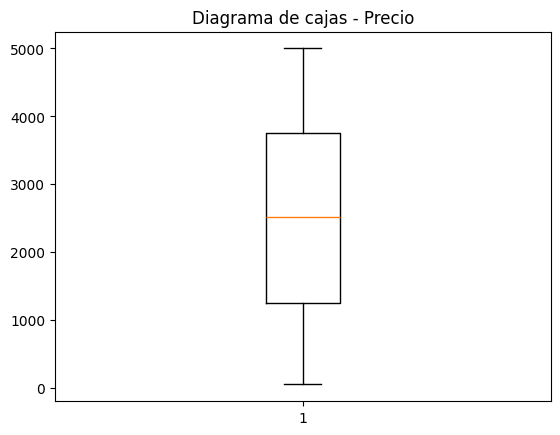

In [6]:
import matplotlib.pyplot as plt

plt.boxplot(df_mongo['precio'])
plt.title("Diagrama de cajas - Precio")
plt.show()

# Dispersión

La gráfica de dispersión muestra la relación entre el precio y el total de venta. Se observa una tendencia positiva, lo que indica que a medida que aumenta el precio del producto, también se incrementa el total de la venta. Asimismo, la gran cantidad de puntos refleja el volumen de datos analizados.

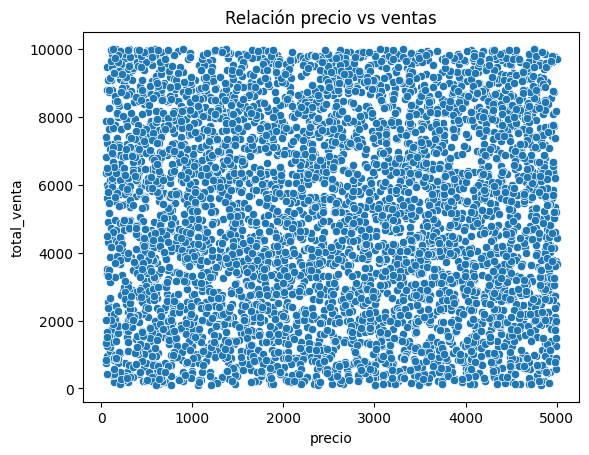

In [7]:
import seaborn as sns

sns.scatterplot(x=df_mongo['precio'], y=df_mongo['total_venta'])
plt.title("Relación precio vs ventas")
plt.show()

# Histograma

El histograma permite analizar la distribución del total de ventas, mostrando la frecuencia con la que ocurren ciertos rangos de valores. Se observa que las ventas se concentran en determinados intervalos, lo que indica un comportamiento de compra recurrente en esos rangos.

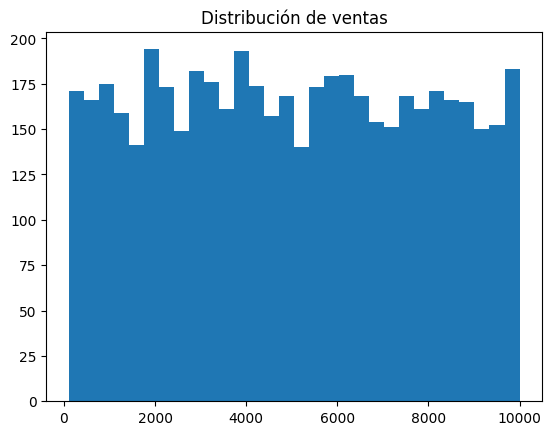

In [8]:
plt.hist(df_mongo['total_venta'], bins=30)
plt.title("Distribución de ventas")
plt.show()